In [15]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [16]:
import pandas as pd

print("--- 🚀 开始数据清洗与合并 ---")

# 1. 读取两个数据集
df_1 = pd.read_csv('data.csv')
df_2 = pd.read_csv('stock_sentiment.csv')

print(f"合并前: data.csv 有 {len(df_1)} 行")
print(f"合并前: stock_sentiment.csv 有 {len(df_2)} 行")

# 2. 统一 df_2 (stock_sentiment) 的列名和标签
# 将 'Text' 列名改为 'Sentence'
df_2 = df_2.rename(columns={'Text': 'Sentence'})

# 将数字 1 和 0 转换为文字
# 假设 1 是 positive, 0 是 negative
sentiment_mapping = {1: 'positive', 0: 'negative'}
df_2['Sentiment'] = df_2['Sentiment'].map(sentiment_mapping)

# 3. 将它们上下拼接起来
merged_df = pd.concat([df_1, df_2], ignore_index=True)

# 4. 去除可能重复的句子
before_drop = len(merged_df)
merged_df = merged_df.drop_duplicates(subset=['Sentence'])
after_drop = len(merged_df)
print(f"去除了 {before_drop - after_drop} 条重复的句子！")

# 5. 查看合并后最新的数据分布 (非常重要)
print("\n========== 📊 最新的数据分布 ==========")
print(merged_df['Sentiment'].value_counts())

# 6. 保存为一个干净的终极文件
merged_df.to_csv('final_cleaned_data.csv', index=False)
print("\n✅ 大功告成！已保存为 'final_cleaned_data.csv'")

--- 🚀 开始数据清洗与合并 ---
合并前: data.csv 有 5842 行
合并前: stock_sentiment.csv 有 5791 行
去除了 520 条重复的句子！

========== 📊 最新的数据分布 ==========
Sentiment
positive    5537
neutral     2878
negative    2698
Name: count, dtype: int64

✅ 大功告成！已保存为 'final_cleaned_data.csv'


In [19]:
%pip install transformers torch

Note: you may need to restart the kernel to use updated packages.


1. Loading data...
Data loaded successfully! Total valid records: 11113

2. Splitting dataset (80% Training, 20% Testing)...

3. Extracting text features (TF-IDF + Bi-grams)...

4. Training Linear SVC model...

5. Evaluating model...

          Classification Report
              precision    recall  f1-score   support

    negative       0.71      0.60      0.65       561
     neutral       0.79      0.80      0.79       575
    positive       0.77      0.82      0.79      1087

    accuracy                           0.76      2223
   macro avg       0.75      0.74      0.74      2223
weighted avg       0.76      0.76      0.76      2223



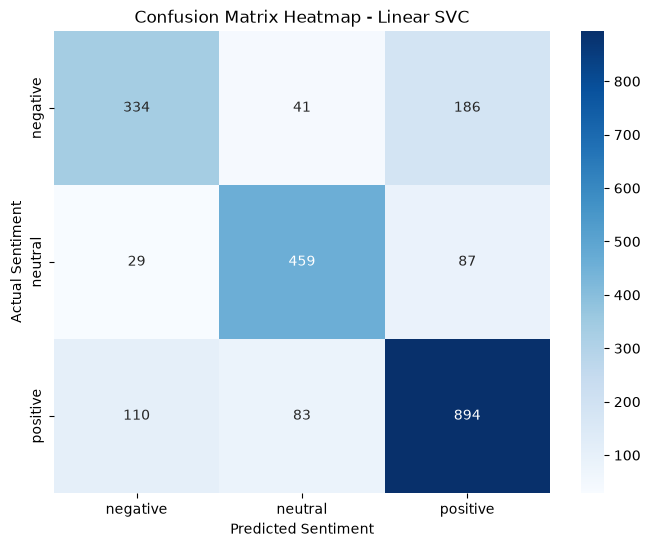

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("1. Loading data...")
# Update this path if needed
file_path = 'final_cleaned_data.csv'
df = pd.read_csv(file_path).dropna()

X = df['Sentence']
y = df['Sentiment']
print(f"Data loaded successfully! Total valid records: {len(df)}")

print("\n2. Splitting dataset (80% Training, 20% Testing)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n3. Extracting text features (TF-IDF + Bi-grams)...")
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=3, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("\n4. Training Linear SVC model...")
model_svc = LinearSVC(C=1.0, random_state=42, max_iter=2000)
model_svc.fit(X_train_vec, y_train)

print("\n5. Evaluating model...")
preds = model_svc.predict(X_test_vec)

# Print Accuracy, Precision, Recall, F1-score
print("\n" + "="*40)
print("          Classification Report")
print("="*40)
print(classification_report(y_test, preds))

# Generate Confusion Matrix Heatmap
cm = confusion_matrix(y_test, preds)
target_names = sorted(y.unique()) # Get sorted class names (e.g., negative, neutral, positive)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('Confusion Matrix Heatmap - Linear SVC')
plt.show()

1. Loading and encoding data...
2. Tokenizing text sequences...
3. Building Bi-LSTM model...
4. Training Bi-LSTM model...
Epoch 1/3
278/278 ━━━━━━━━━━━━━━━━━━━━ 34s 92ms/step - accuracy: 0.6264 - loss: 0.8250 - val_accuracy: 0.7296 - val_loss: 0.6275
Epoch 2/3
278/278 ━━━━━━━━━━━━━━━━━━━━ 22s 79ms/step - accuracy: 0.8177 - loss: 0.4751 - val_accuracy: 0.7629 - val_loss: 0.5807
Epoch 3/3
278/278 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - accuracy: 0.8981 - loss: 0.2903 - val_accuracy: 0.7490 - val_loss: 0.6967

5. Evaluating model...
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step

          Classification Report
              precision    recall  f1-score   support

    negative       0.69      0.57      0.62       561
     neutral       0.82      0.75      0.78       575
    positive       0.74      0.84      0.79      1087

    accuracy                           0.75      2223
   macro avg       0.75      0.72      0.73      2223
weighted avg       0.75      0.75      0.75      2223



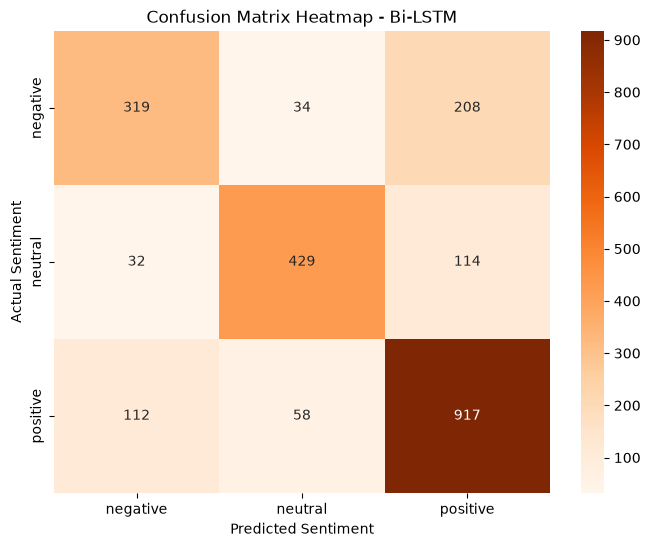

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout

print("1. Loading and encoding data...")
df = pd.read_csv('final_cleaned_data.csv').dropna()
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(df['Sentiment'])
X = df['Sentence']

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print("2. Tokenizing text sequences...")
max_words = 10000
max_len = 100
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len)

print("3. Building Bi-LSTM model...")
model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("4. Training Bi-LSTM model...")
history = model.fit(X_train_seq, y_train, validation_data=(X_test_seq, y_test), epochs=3, batch_size=32)

print("\n5. Evaluating model...")
# Predict probabilities and convert to class labels
pred_probs = model.predict(X_test_seq)
preds = np.argmax(pred_probs, axis=1)

print("\n" + "="*40)
print("          Classification Report")
print("="*40)
target_names = encoder.classes_
print(classification_report(y_test, preds, target_names=target_names))

# Generate Confusion Matrix Heatmap
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('Confusion Matrix Heatmap - Bi-LSTM')
plt.show()